<a href="https://colab.research.google.com/github/CaptainMarlow/IAD_labs/blob/main/IAD_Lab4P2_Sliepyi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 30
LATENT_DIM = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Data loaded. Device used: {DEVICE}")

Data loaded. Device used: cuda


In [42]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc2_mu = nn.Linear(400, LATENT_DIM)
        self.fc2_logvar = nn.Linear(400, LATENT_DIM)
        self.relu = nn.ReLU()

        self.fc3 = nn.Linear(LATENT_DIM, 400)
        self.fc4 = nn.Linear(400, 784)
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h1 = self.relu(self.fc1(x))
        return self.fc2_mu(h1), self.fc2_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = self.relu(self.fc3(z))
        return self.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)

In [43]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [44]:
model.train()
for epoch in range(EPOCHS):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(DEVICE)

        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)

        loss = loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f'Epoch: {epoch+1} | Average Loss: {train_loss / len(train_loader.dataset):.4f}')

print("Training finished!")

Epoch: 1 | Average Loss: 286.7175
Epoch: 2 | Average Loss: 261.4580
Epoch: 3 | Average Loss: 252.0961
Epoch: 4 | Average Loss: 247.9714
Epoch: 5 | Average Loss: 246.0680
Epoch: 6 | Average Loss: 244.7923
Epoch: 7 | Average Loss: 243.9983
Epoch: 8 | Average Loss: 243.3902
Epoch: 9 | Average Loss: 242.9003
Epoch: 10 | Average Loss: 242.4382
Epoch: 11 | Average Loss: 242.1572
Epoch: 12 | Average Loss: 241.8338
Epoch: 13 | Average Loss: 241.6376
Epoch: 14 | Average Loss: 241.4243
Epoch: 15 | Average Loss: 241.2313
Epoch: 16 | Average Loss: 241.0563
Epoch: 17 | Average Loss: 240.8630
Epoch: 18 | Average Loss: 240.7623
Epoch: 19 | Average Loss: 240.6254
Epoch: 20 | Average Loss: 240.5176
Epoch: 21 | Average Loss: 240.4095
Epoch: 22 | Average Loss: 240.3051
Epoch: 23 | Average Loss: 240.2732
Epoch: 24 | Average Loss: 240.1493
Epoch: 25 | Average Loss: 240.0468
Epoch: 26 | Average Loss: 239.9997
Epoch: 27 | Average Loss: 239.9269
Epoch: 28 | Average Loss: 239.8422
Epoch: 29 | Average Loss: 239

Згенеровані зразки одягу:


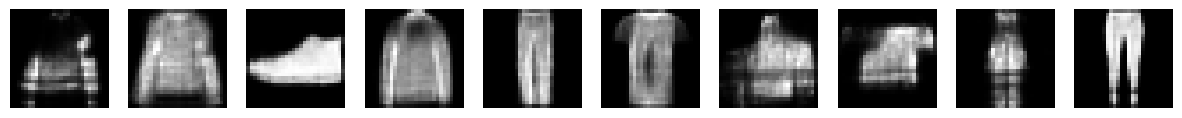

In [48]:
def generate_images(num_images=10):
    model.eval()
    with torch.no_grad():
        # Генеруємо випадковий шум з нормального розподілу
        z = torch.randn(num_images, LATENT_DIM).to(DEVICE)

        # Проганяємо через декодер
        generated = model.decode(z).cpu()

        # Відображення
        plt.figure(figsize=(15, 3))
        for i in range(num_images):
            plt.subplot(1, num_images, i+1)
            plt.imshow(generated[i].view(28, 28), cmap='gray')
            plt.axis('off')
        plt.show()

print("Згенеровані зразки одягу:")
generate_images()